In [513]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [515]:
df = pd.read_csv("diabetes_screening_data.csv")

In [517]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [520]:
df.shape

(768, 9)

In [522]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [524]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [526]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [528]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [530]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [532]:
df['Glucose'].unique() 

array([148,  85, 183,  89, 137, 116,  78, 115, 197, 125, 110, 168, 139,
       189, 166, 100, 118, 107, 103, 126,  99, 196, 119, 143, 147,  97,
       145, 117, 109, 158,  88,  92, 122, 138, 102,  90, 111, 180, 133,
       106, 171, 159, 146,  71, 105, 101, 176, 150,  73, 187,  84,  44,
       141, 114,  95, 129,  79,   0,  62, 131, 112, 113,  74,  83, 136,
        80, 123,  81, 134, 142, 144,  93, 163, 151,  96, 155,  76, 160,
       124, 162, 132, 120, 173, 170, 128, 108, 154,  57, 156, 153, 188,
       152, 104,  87,  75, 179, 130, 194, 181, 135, 184, 140, 177, 164,
        91, 165,  86, 193, 191, 161, 167,  77, 182, 157, 178,  61,  98,
       127,  82,  72, 172,  94, 175, 195,  68, 186, 198, 121,  67, 174,
       199,  56, 169, 149,  65, 190], dtype=int64)

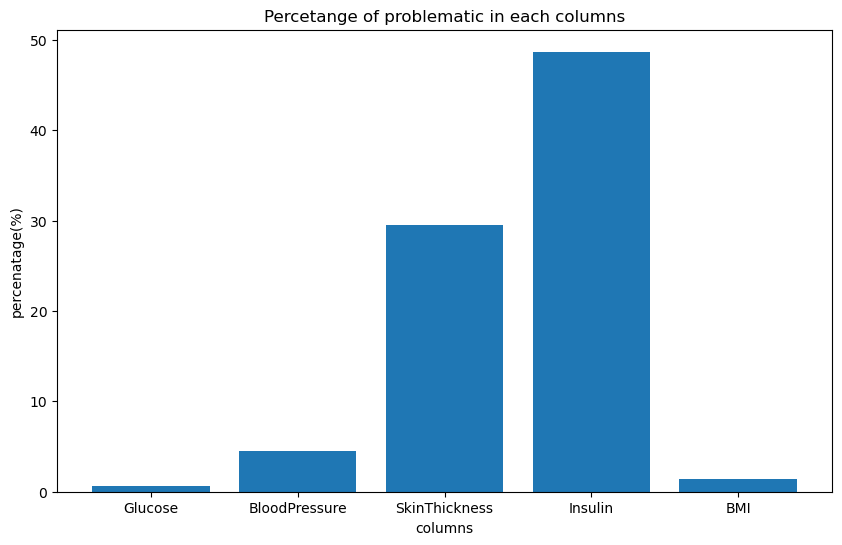

In [534]:
# problamatic values
# find the percentage of 0 values 
columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
percentage  = []

for col in columns:
    zero = (df[col]==0).sum()
    percent = (zero/len(df)) *100 # calcuate the percetange of 0 values 
    percentage.append(percent)

# create the chart 
plt.figure(figsize = (10,6))
plt.bar(columns,percentage)

plt.title('Percetange of problematic in each columns')
plt.xlabel('columns')
plt.ylabel('percenatage(%)')

plt.savefig('problematic_values_in_each_columns',dpi =300)
plt.show()


In [535]:
df['Age'].unique()   # check for every columns

array([50, 31, 32, 21, 33, 30, 26, 29, 53, 54, 34, 57, 59, 51, 27, 41, 43,
       22, 38, 60, 28, 45, 35, 46, 56, 37, 48, 40, 25, 24, 58, 42, 44, 39,
       36, 23, 61, 69, 62, 55, 65, 47, 52, 66, 49, 63, 67, 72, 81, 64, 70,
       68], dtype=int64)

In [538]:
# Find every column that contains impossible values. Explain in one sentence why they are impossible
# and how you will treat them.
#-- Columns having zero values might create problem during the prediction of the model
col_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

In [540]:
for col in col_with_zero:
    df[col] = df[col].replace(0,np.nan)

In [542]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [544]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [546]:
# now i have to remove the null values with median values because median is robust of outlier 
for  col in col_with_zero:
    df[col].fillna(df[col].median(),inplace= True)

C:\Users\manoj\AppData\Local\Temp\ipykernel_4948\3916507707.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace= True)


In [548]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [550]:
df.isnull().sum()   #-- No NAN values is present 

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [552]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [554]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [556]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


In [558]:
# now calculate the diabetics vs non diabetic

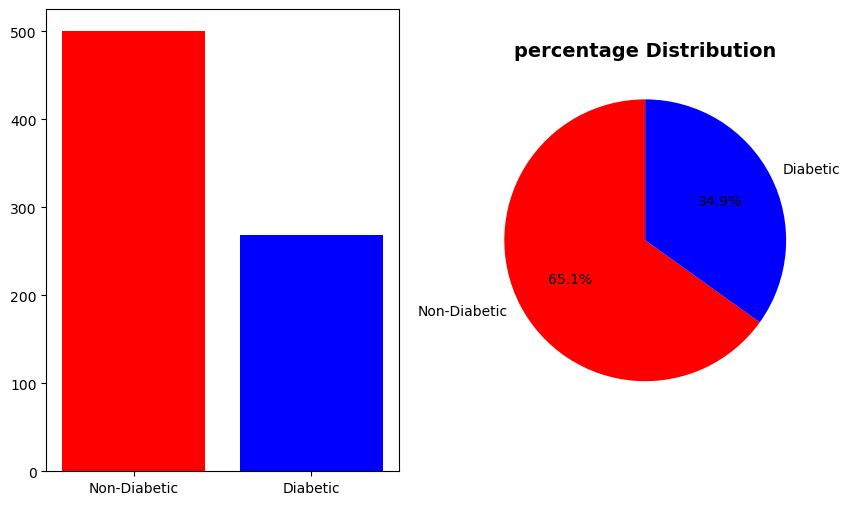

In [560]:
plt.figure(figsize = (10,6))
plt.subplot(1,2,1)
outcome_count = df['Outcome'].value_counts()
plt.bar(['Non-Diabetic','Diabetic'],outcome_count.values,color = ['red','blue'])

plt.subplot(1,2,2)
plt.pie(outcome_count.values,labels=['Non-Diabetic','Diabetic'],colors=['red','blue'],startangle=90,autopct='%1.1f%%')
plt.title('percentage Distribution', fontsize=14,fontweight='bold')
plt.savefig('diabetics vs non diabetic',dpi =300)
plt.show()

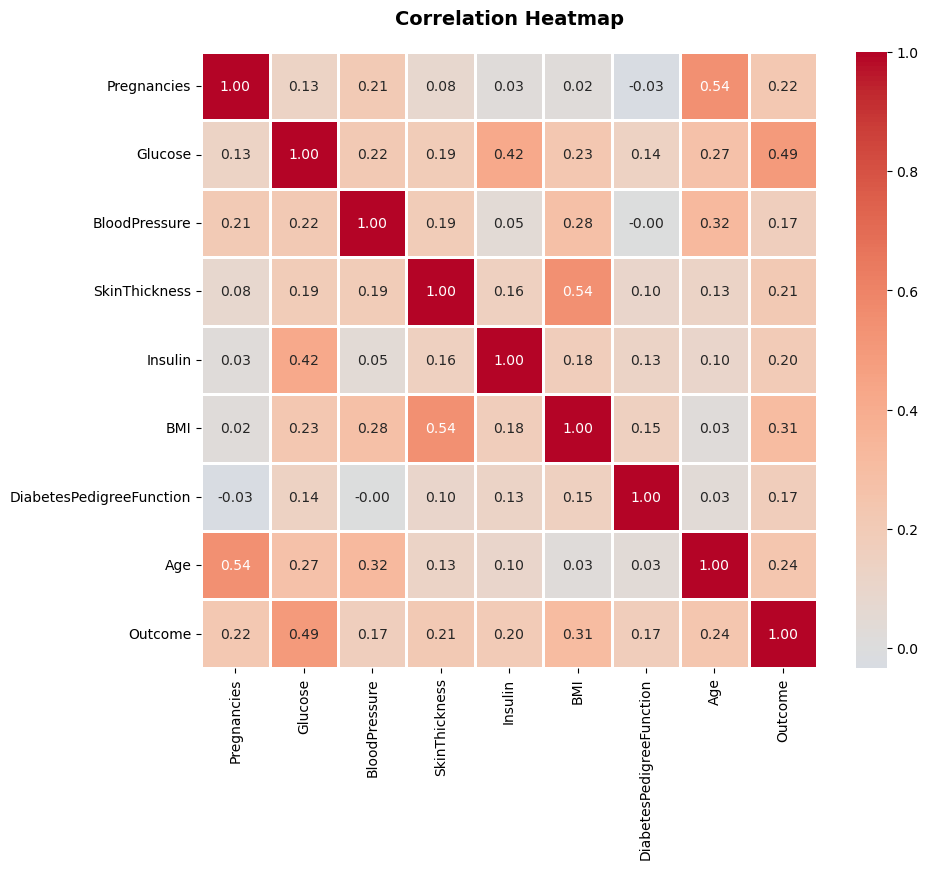

In [561]:
# correlation heatmap
plt.figure(figsize=(10,8))
correlation = df.corr()
sns.heatmap(correlation,annot =True,cmap = 'coolwarm',center =0,square=True,linewidth =1,fmt='.2f')
plt.title('Correlation Heatmap',fontsize=14,pad=20,fontweight='bold')
plt.savefig('Correlation HeatMap',dpi =300)
plt.show()

In [563]:
"""
Observations from correlation heatmap

1. Glucose has the strongest positive correlation with the Outcome, so it appears to be an important feature for diabetes prediction.
2. BMI and Age also show a positive relationship with diabetes Outcome.
3. Pregnancies and DiabetesPedigreeFunction show a moderate positive relationship with the Outcome.
4. BloodPressure and SkinThickness have relatively weak correlations with the Outcome.
5. Correlation shows the strength of linear relationships, so a weak correlation does not necessarily mean that a feature is useless for machine learning."""

'\nObservations from correlation heatmap\n\n1. Glucose has the strongest positive correlation with the Outcome, so it appears to be an important feature for diabetes prediction.\n2. BMI and Age also show a positive relationship with diabetes Outcome.\n3. Pregnancies and DiabetesPedigreeFunction show a moderate positive relationship with the Outcome.\n4. BloodPressure and SkinThickness have relatively weak correlations with the Outcome.\n5. Correlation shows the strength of linear relationships, so a weak correlation does not necessarily mean that a feature is useless for machine learning.'

In [564]:
# Feature scaling 
# • Create at least 3 new features using domain logic (examples: a flag for a missing measurement, an
# obesity flag from BMI, a product of two risk factors). Justify each in one line.

# 1. Obesity Flag-----BMI Obesity Flag → whether BMI is 30 or above.
df['obesity'] = (df['BMI'] >= 30).astype(int)

# 2. Glucose and BMI interaction --Glucose × BMI → combines two diabetes-related risk factors.
df['Glucose_BMI'] = df['Glucose'] * df['BMI']

#3-Age and glucose interaction ---Age × Glucose → combines age and glucose level.
df['Age_Glucose'] = df['Age']*df['Glucose']

In [565]:
df.head() #-- three new col added 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,obesity,Glucose_BMI,Age_Glucose
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1,4972.8,7400.0
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,0,2261.0,2635.0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,0,4263.9,5856.0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,0,2500.9,1869.0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1,5904.7,4521.0


In [566]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,mean_absolute_error,classification_report
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold

In [572]:

# train test split 

In [574]:
# Now i have to put 'outcome ' in 1-axis and other variable in other -axis (Target variable is outcome)
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [576]:
print(X.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'obesity', 'Glucose_BMI',
       'Age_Glucose'],
      dtype='object')


In [578]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [580]:
# train test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [582]:
logistic_model = LogisticRegression(max_iter=500)

scores = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("ROC-AUC Mean:", scores["test_score"].mean())
print("ROC-AUC Std:", scores["test_score"].std())

C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

ROC-AUC Mean: 0.8343757263169408
ROC-AUC Std: 0.019594786291078217


C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

In [583]:
print(X.shape) # --- whole data set 

(768, 11)


In [586]:
print(X_train.shape) #-- This data is for training the model

(614, 11)


In [588]:
print(X_test.shape) # -- This data is used for testing the model

(154, 11)


# 1. First Model -- Logistic Regression 

In [591]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


model = LogisticRegression()
model.fit(X_train_scaled,y_train)

In [594]:
y_pred = model.predict(X_test_scaled)

In [596]:
acc = accuracy_score(y_test,y_pred)

In [598]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
      dtype=int64)

In [600]:
y_test

668    0
324    0
624    0
690    0
473    0
      ..
355    1
534    0
344    0
296    1
462    0
Name: Outcome, Length: 154, dtype: int64

In [602]:
print(acc)

0.8181818181818182


In [604]:
confusion_matrix(y_test,y_pred)

array([[88, 11],
       [17, 38]], dtype=int64)

In [606]:
print(print(classification_report(y_test,y_pred)))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86        99
           1       0.78      0.69      0.73        55

    accuracy                           0.82       154
   macro avg       0.81      0.79      0.80       154
weighted avg       0.82      0.82      0.82       154

None


In [608]:
roc_auc_mean = scores["test_score"].mean()
roc_auc_std = scores["test_score"].std()

print("ROC-AUC Mean:", roc_auc_mean)
print("ROC-AUC Std:", roc_auc_std)

ROC-AUC Mean: 0.8343757263169408
ROC-AUC Std: 0.019594786291078217


# 2. KNN (K-Nearest Neighbors) Algorithm 

In [612]:
scaler = StandardScaler()

In [614]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [616]:
knn_model = KNeighborsClassifier(n_neighbors=5)


In [618]:
knn_model.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [620]:
y_pred_knn  = knn_model.predict(X_test_scaled)

In [622]:
accuracy_score(y_test,y_pred_knn)

0.6948051948051948

In [624]:
confusion_matrix(y_test,y_pred_knn)

array([[73, 26],
       [21, 34]], dtype=int64)

In [626]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76        99
           1       0.57      0.62      0.59        55

    accuracy                           0.69       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.69      0.70       154



In [628]:
knn_model = KNeighborsClassifier()

scores = cross_validate(
    knn_model,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc"
)

print("ROC-AUC Mean:", scores["test_score"].mean())
print("ROC-AUC Std:", scores["test_score"].std())

ROC-AUC Mean: 0.7891099370411386
ROC-AUC Std: 0.013775063295915666


# 3.Naive bayes algorithm

In [631]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,obesity,Glucose_BMI,Age_Glucose
60,2,84.0,72.0,29.0,125.0,32.3,0.304,21,1,2713.2,1764.0
618,9,112.0,82.0,24.0,125.0,28.2,1.282,50,0,3158.4,5600.0
346,1,139.0,46.0,19.0,83.0,28.7,0.654,22,0,3989.3,3058.0
294,0,161.0,50.0,29.0,125.0,21.9,0.254,65,0,3525.9,10465.0
231,6,134.0,80.0,37.0,370.0,46.2,0.238,46,1,6190.8,6164.0
...,...,...,...,...,...,...,...,...,...,...,...
71,5,139.0,64.0,35.0,140.0,28.6,0.411,26,0,3975.4,3614.0
106,1,96.0,122.0,29.0,125.0,22.4,0.207,27,0,2150.4,2592.0
270,10,101.0,86.0,37.0,125.0,45.6,1.136,38,1,4605.6,3838.0
435,0,141.0,72.0,29.0,125.0,42.4,0.205,29,1,5978.4,4089.0


In [633]:
model_NB = GaussianNB()

In [635]:
model_NB.fit(X_train,y_train)

GaussianNB()

In [637]:
y_pred_NB = model_NB.predict(X_test)

In [639]:
y_pred_NB

array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
      dtype=int64)

In [641]:
accuracy_score(y_test,y_pred_NB)

0.7402597402597403

In [643]:
confusion_matrix(y_test,y_pred_NB)

array([[77, 22],
       [18, 37]], dtype=int64)

In [645]:
print(classification_report(y_test,y_pred_NB))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79        99
           1       0.63      0.67      0.65        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



In [647]:
nb_model = GaussianNB()

scores = cross_validate(
    nb_model,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc"
)

print("ROC-AUC Mean:", scores["test_score"].mean())
print("ROC-AUC Std:", scores["test_score"].std())

ROC-AUC Mean: 0.8255774134230206
ROC-AUC Std: 0.01977814332500944


# 4.Decision Tree Algorithm 


In [651]:
X_train_scaled

array([[-5.26396861e-01, -1.25688146e+00, -1.89952596e-02, ...,
         7.82015701e-01, -8.70587082e-01, -1.13744879e+00],
       [ 1.58804586e+00, -3.26050666e-01,  8.08174200e-01, ...,
        -1.27874670e+00, -5.66583490e-01,  7.27304997e-01],
       [-8.28460107e-01,  5.71536173e-01, -2.16963585e+00, ...,
        -1.27874670e+00,  7.94282573e-04, -5.08410367e-01],
       ...,
       [ 1.89010910e+00, -6.91734193e-01,  1.13904198e+00, ...,
         7.82015701e-01,  4.21633037e-01, -1.29237281e-01],
       [-1.13052335e+00,  6.38024087e-01, -1.89952596e-02, ...,
         7.82015701e-01,  1.35904573e+00, -7.22132656e-03],
       [-1.13052335e+00,  1.06120775e-01,  1.96621144e+00, ...,
        -1.27874670e+00, -8.02780351e-01, -7.18900041e-01]])

In [653]:
model_Decision_Tree  = DecisionTreeClassifier(random_state = 42)

In [655]:
model_Decision_Tree.fit(X_train_scaled,y_train)

DecisionTreeClassifier(random_state=42)

In [657]:
y_pred_Decision_Tree = model_Decision_Tree.predict(X_test_scaled)

In [659]:
y_pred_Decision_Tree

array([0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0],
      dtype=int64)

In [661]:
accuracy_score(y_test,y_pred_Decision_Tree)

0.6688311688311688

In [663]:
confusion_matrix(y_test,y_pred_Decision_Tree)

array([[75, 24],
       [27, 28]], dtype=int64)

In [665]:
print(classification_report(y_test,y_pred_Decision_Tree))

              precision    recall  f1-score   support

           0       0.74      0.76      0.75        99
           1       0.54      0.51      0.52        55

    accuracy                           0.67       154
   macro avg       0.64      0.63      0.63       154
weighted avg       0.66      0.67      0.67       154



In [667]:
dt_model = DecisionTreeClassifier(random_state=42)

scores = cross_validate(
    dt_model,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc"
)

print("ROC-AUC Mean:", scores["test_score"].mean())
print("ROC-AUC Std:", scores["test_score"].std())

ROC-AUC Mean: 0.6603575017431608
ROC-AUC Std: 0.02644950268682093


# 5.SVM (Support Vector Machine )

In [670]:
model_svm = SVC(kernel ='rbf')

In [672]:
model_svm.fit(X_train_scaled,y_train)

SVC()

In [674]:
y_pred_svc = model_svm.predict(X_test_scaled)

In [676]:
y_pred_svc

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
      dtype=int64)

In [678]:
accuracy_score(y_test,y_pred_svc)

0.7597402597402597

In [680]:
confusion_matrix(y_test,y_pred_svc)

array([[85, 14],
       [23, 32]], dtype=int64)

In [682]:
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82        99
           1       0.70      0.58      0.63        55

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.75       154



In [684]:
svm_model = SVC(probability=True, random_state=42)

scores = cross_validate(
    svm_model,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc"
)

print("ROC-AUC Mean:", scores["test_score"].mean())
print("ROC-AUC Std:", scores["test_score"].std())

ROC-AUC Mean: 0.8434471172907865
ROC-AUC Std: 0.016835884485851226


In [686]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True)
}

In [688]:
results = []
for name, model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    results.append({
        'Model':name,
        'Accuracy': round(acc,4),
        'F1 Score': round(f1,4)
    })

In [690]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.7727, 'F1 Score': 0.6602},
 {'Model': 'KNN', 'Accuracy': 0.6948, 'F1 Score': 0.5913},
 {'Model': 'Naive Bayes', 'Accuracy': 0.7468, 'F1 Score': 0.6486},
 {'Model': 'Decision Tree', 'Accuracy': 0.6883, 'F1 Score': 0.5789},
 {'Model': 'SVM (RBF Kernel)', 'Accuracy': 0.7597, 'F1 Score': 0.6337}]

In [692]:
# from all the model , i can see that the best accuracy is given by -- Logistics regression model

# BONUS CHALLENGE

In [695]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

features = ["BloodPressure", "SkinThickness", "BMI", "Age"]

X = df[features]
y = df["Glucose"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

Linear_model = LinearRegression()
Linear_model.fit(X_train, y_train)

y_pred = Linear_model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R² Score: 0.09210375756432987
MAE: 24.913287250555808


In [697]:
# Now dumbe the model in Logistic Regression

In [699]:
import joblib

In [702]:
# ==========================================
# FINAL LOGISTIC REGRESSION MODEL FOR APP
# ==========================================

# Create classification features again
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(
    X_train_scaled,
    y_train
)

# Save model
joblib.dump(
    logistic_model,
    "Diabetes_Disease_prediction.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

# Save correct feature names
joblib.dump(
    X.columns.tolist(),
    "columns.pkl"
)

print("Model saved successfully!")
print("Number of features:", len(X.columns))
print("Features:", X.columns.tolist())

Model saved successfully!
Number of features: 11
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'obesity', 'Glucose_BMI', 'Age_Glucose']


In [705]:
joblib.dump(models["Logistic Regression"], "Diabetes_Disease_prediction.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']